# Yuyao Personal EDA and Advanced Modeling

**Research question:** Can basic building characteristics predict `Weather Normalized Site EUI (kBtu/ft²)`?

This notebook continues from the shared-cleaned dataset and upgrades the original baseline analysis into a stronger final-project workflow. It keeps the interpretable baseline models, then adds boosting, subset-based tuning, feature-importance analysis, robustness checks, and post-model diagnostic analysis.

The workflow is organized into eight stages:
1. Personal EDA for the target and selected features
2. Final feature selection based on the EDA
3. Final preprocessing decisions for the first stable modeling subset
4. Baseline, boosting, and nonlinear model comparison
5. Random-forest tuning, feature importance, and sensitivity analysis
6. Residual and error analysis for the tuned random forest
7. Tuned-vs-baseline random-forest comparison
8. Final project-oriented findings with model-level interpretation


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")


In [3]:
file_path = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"

target = "Weather Normalized Site EUI (kBtu/ft²)"
features = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Primary Property Type - Self Selected",
    "City",
]

df = pd.read_csv(file_path, usecols=lambda c: c in features + [target], low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (103259, 6)


,City,Primary Property Type - Self Selected,Year Built,Number of Buildings,Weather Normalized Site EUI (kBtu/ft²),Property GFA - Self-Reported (ft²)
0,Queens,Non-Refrigerated Warehouse,1930,1,10.6,51749.0
1,Bronx,Multifamily Housing,1960,1,58.5,52941.0
2,Far Rockaway,Mixed Use Property,1941,1,64.1,35196.0
3,New York,Multifamily Housing,1898,1,69.0,107234.0
4,Queens,Medical Office,1911,1,50.9,75191.0


## 1. Personal EDA

The personal EDA focuses only on the selected target and basic building characteristics used in this individual project.

In [7]:
eda_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "nunique": df.nunique(dropna=True),
})

eda_summary

,dtype,missing_count,missing_rate,nunique
City,object,0,0.000000,386
Primary Property Type - Self Selected,object,0,0.000000,84
Year Built,int64,0,0.000000,204
Number of Buildings,int64,0,0.000000,99
Weather Normalized Site EUI (kBtu/ft²),float64,17240,0.166959,3919
Property GFA - Self-Reported (ft²),float64,0,0.000000,32596


In [9]:
target_series = df[target].dropna()

target_summary = pd.Series({
    "count": target_series.shape[0],
    "missing_rate": df[target].isna().mean(),
    "nonpositive_count": (target_series <= 0).sum(),
    "skew": target_series.skew(),
    "p99": target_series.quantile(0.99),
    "p999": target_series.quantile(0.999),
    "max": target_series.max(),
})

target_summary

count                8.601900e+04
missing_rate         1.669588e-01
nonpositive_count    2.160000e+02
skew                 4.037552e+01
p99                  4.122560e+02
p999                 2.597570e+06
max                  1.629255e+07
dtype: float64

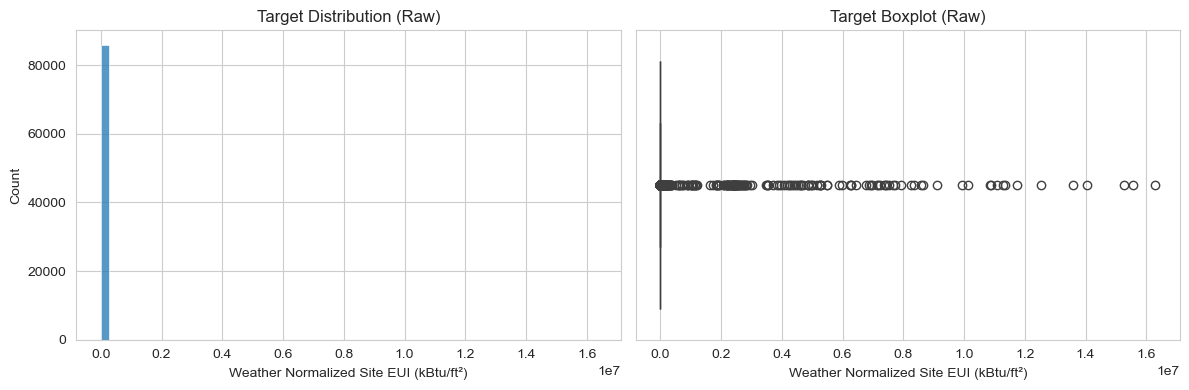

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(target_series, bins=60, ax=axes[0])
axes[0].set_title("Target Distribution (Raw)")
axes[0].set_xlabel(target)

sns.boxplot(x=target_series, ax=axes[1])
axes[1].set_title("Target Boxplot (Raw)")
axes[1].set_xlabel(target)

plt.tight_layout()
plt.show()

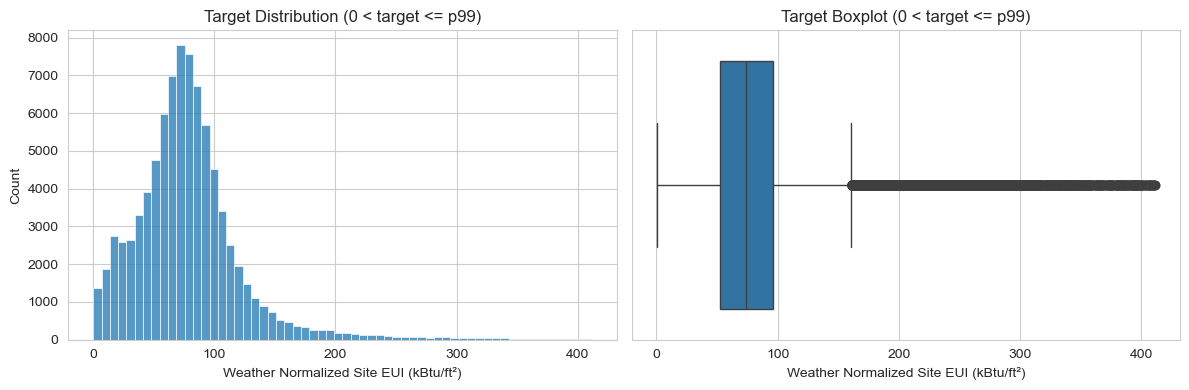

In [13]:
filtered_target = target_series[(target_series > 0) & (target_series <= target_series.quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(filtered_target, bins=60, ax=axes[0])
axes[0].set_title("Target Distribution (0 < target <= p99)")
axes[0].set_xlabel(target)

sns.boxplot(x=filtered_target, ax=axes[1])
axes[1].set_title("Target Boxplot (0 < target <= p99)")
axes[1].set_xlabel(target)

plt.tight_layout()
plt.show()

In [15]:
numeric_features = ["Year Built", "Property GFA - Self-Reported (ft²)", "Number of Buildings"]
categorical_features = ["Primary Property Type - Self Selected", "City"]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Year Built,103259.0,1951.823434,34.843372,1051.0,1926.0,1949.0,1973.0,2088.0
Property GFA - Self-Reported (ft²),103259.0,121126.933305,304478.289583,0.0,34580.0,58765.0,112500.0,21150159.0
Number of Buildings,103259.0,1.348386,4.871286,0.0,1.0,1.0,1.0,514.0


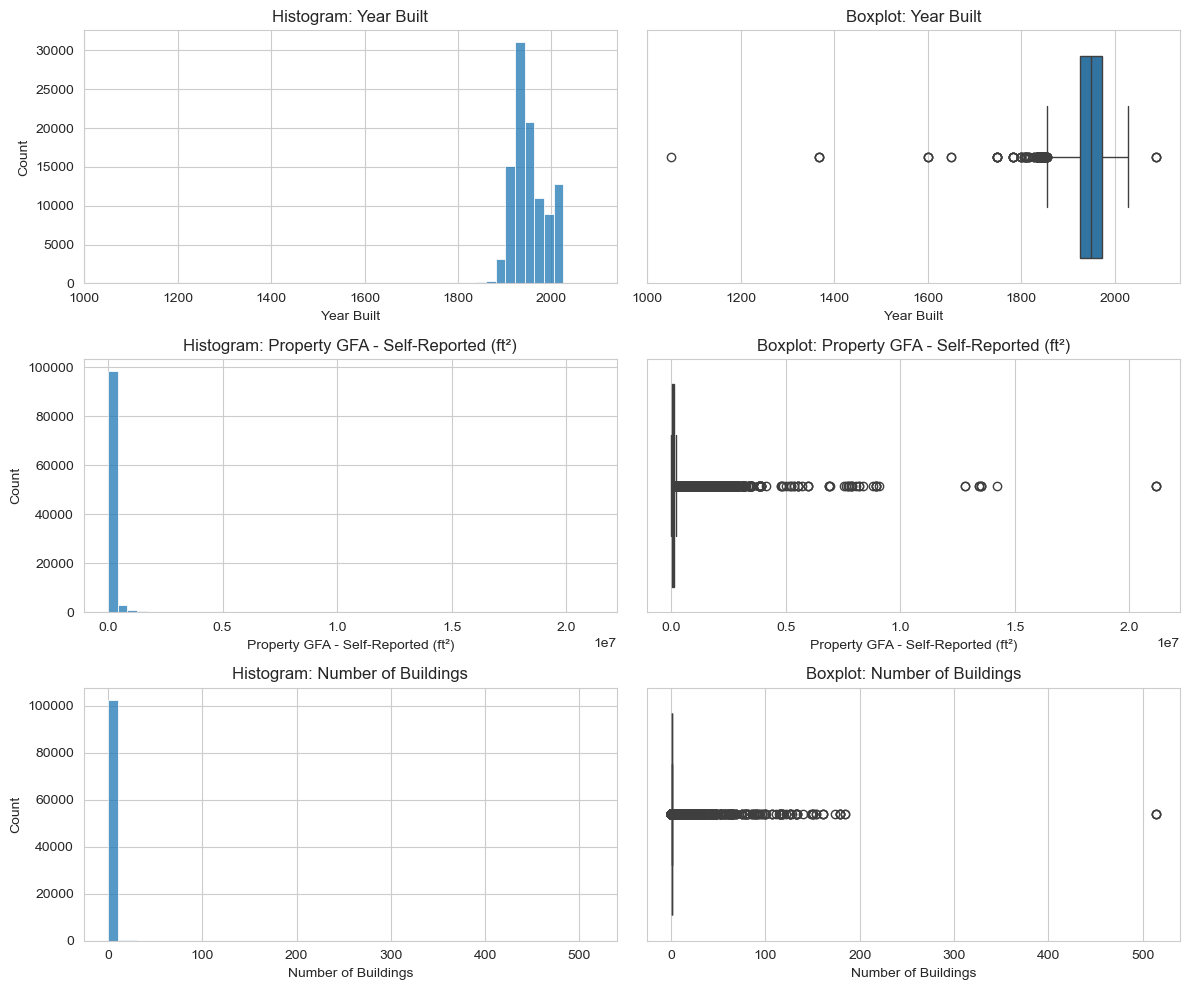

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for idx, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=50, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df[col], ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

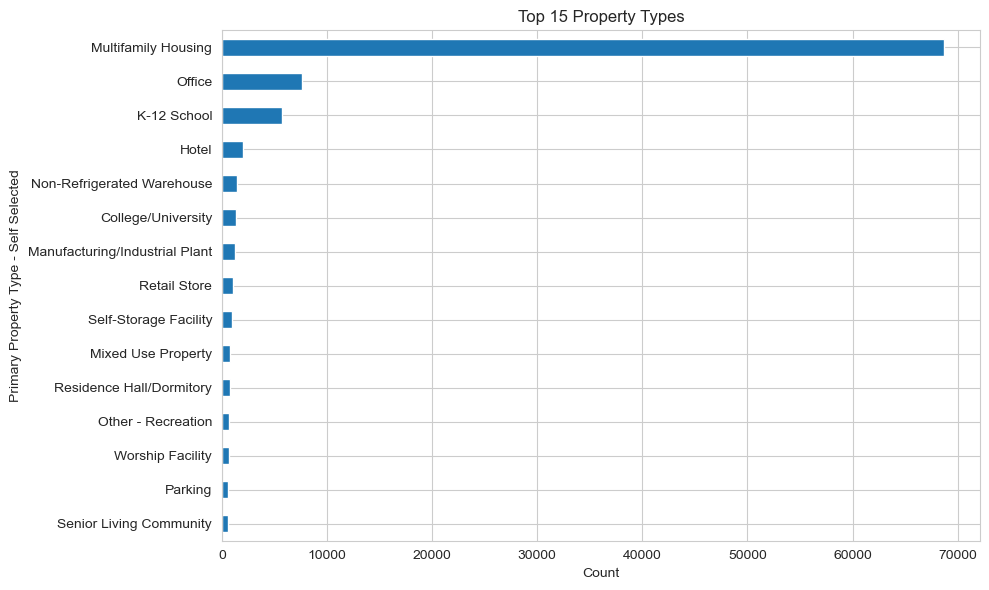

In [18]:
cat_col = "Primary Property Type - Self Selected"
plt.figure(figsize=(10, 6))
df[cat_col].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Property Types")
plt.xlabel("Count")
plt.ylabel(cat_col)
plt.tight_layout()
plt.show()

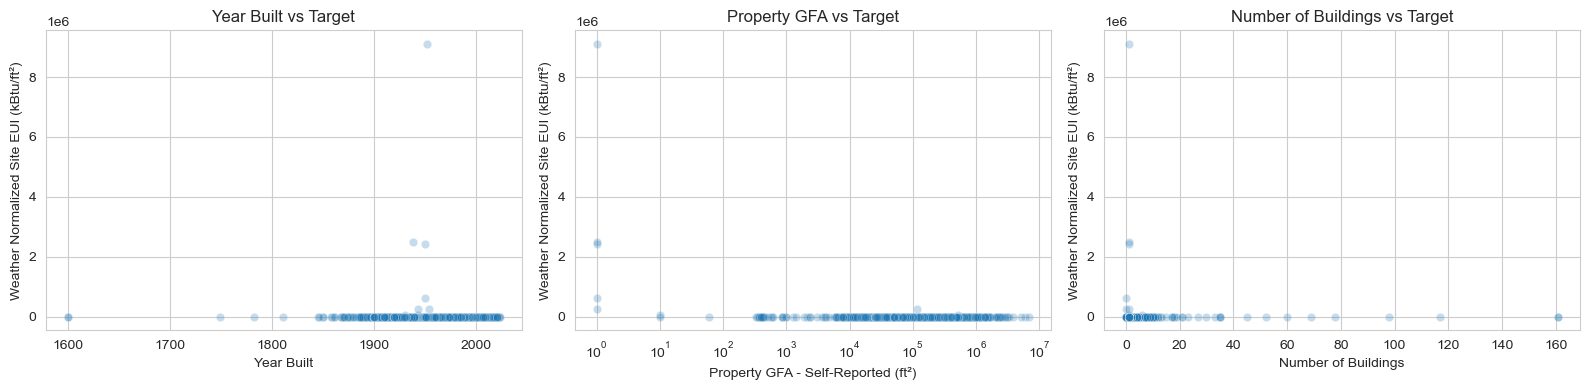

In [21]:
eda_df = df.dropna(subset=[target]).copy()
sample_df = eda_df.sample(min(5000, len(eda_df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=sample_df, x="Year Built", y=target, alpha=0.25, ax=axes[0])
axes[0].set_title("Year Built vs Target")

sns.scatterplot(data=sample_df, x="Property GFA - Self-Reported (ft²)", y=target, alpha=0.25, ax=axes[1])
axes[1].set_title("Property GFA vs Target")
axes[1].set_xscale("log")

sns.scatterplot(data=sample_df, x="Number of Buildings", y=target, alpha=0.25, ax=axes[2])
axes[2].set_title("Number of Buildings vs Target")

plt.tight_layout()
plt.show()

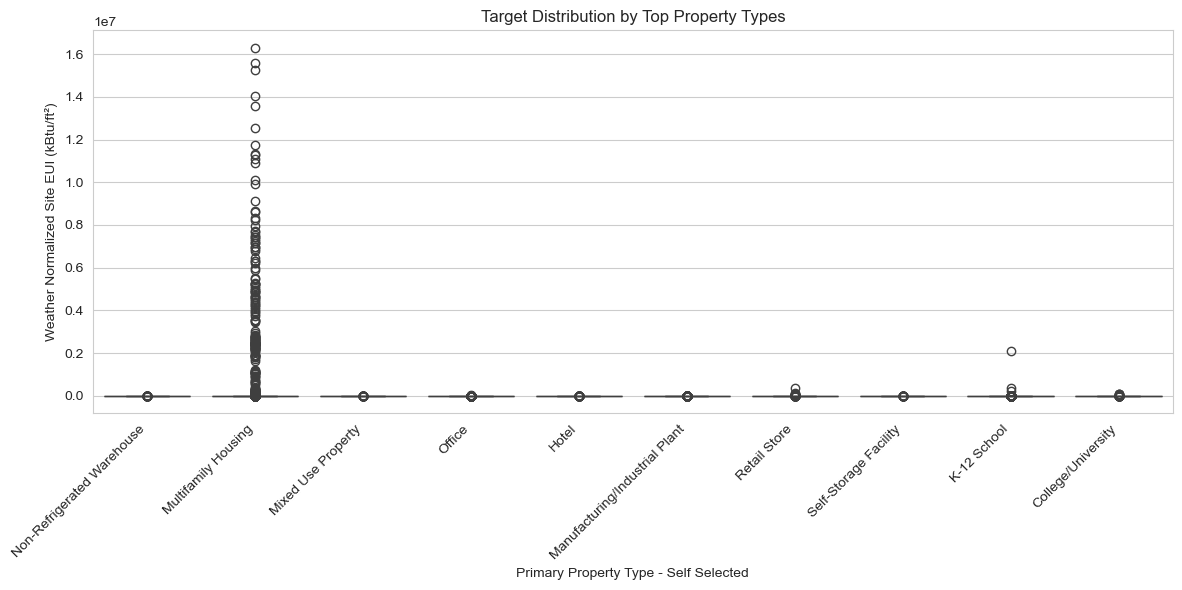

In [23]:
top_types = df[cat_col].value_counts().head(10).index
box_df = eda_df[eda_df[cat_col].isin(top_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=box_df, x=cat_col, y=target)
plt.xticks(rotation=45, ha="right")
plt.title("Target Distribution by Top Property Types")
plt.tight_layout()
plt.show()

**Personal EDA takeaway:** The target is heavily right-skewed and contains a small number of extreme outliers. 
The selected basic building characteristics also show heterogeneous distributions, including wide numeric ranges and imbalanced categorical groups. 
Based on this EDA, the final feature set is kept intentionally small and interpretable, and the first stable modeling subset removes missing targets, excludes nonpositive values, and caps the target at the 99th percentile.


## 2. Final Feature Selection

Based on the personal EDA, the final feature set is restricted to basic building characteristics only:
1. `Year Built`
2. `Property GFA - Self-Reported (ft²)`
3. `Number of Buildings`
4. `Primary Property Type - Self Selected`
5. `City`

These variables were retained because they are consistent with the project scope and provide a simple, interpretable feature set for testing whether basic building metadata can predict weather-normalized EUI. 
Richer energy-use indicators were intentionally excluded to keep this subproject aligned with its stated scope and distinct from other team members’ tasks.


## 3. Final Preprocessing

For the final baseline comparison, rows with missing target values are removed. Nonpositive target values are excluded, and the target is further restricted to observations below the 99th percentile to reduce the influence of extreme outliers. Numerical features are median-imputed, categorical features are mode-imputed, and categorical variables are one-hot encoded.


In [28]:
model_df = df.dropna(subset=[target]).copy()
p99 = model_df[target].quantile(0.99)
model_df = model_df[(model_df[target] > 0) & (model_df[target] <= p99)].copy()

print("Modeling rows:", len(model_df))
print("Target upper threshold (p99):", round(p99, 3))
print("Target skew after filtering:", round(model_df[target].skew(), 3))

Modeling rows: 84942
Target upper threshold (p99): 412.256
Target skew after filtering: 1.99


In [30]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 4. Baseline, Boosting, and Nonlinear Model Comparison


In [33]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
    "XGBRegressor": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    ),
}

results = []
fitted_pipelines = {}
test_predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    fitted_pipelines[name] = pipeline
    test_predictions[name] = predictions

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

baseline_rf_predictions = test_predictions["RandomForestRegressor"]
baseline_rmse = results_df.loc[results_df["model"] == "DummyRegressor", "RMSE"].iloc[0]
best_rmse = results_df["RMSE"].min()
best_model_name = results_df.loc[results_df["RMSE"].idxmin(), "model"]
rmse_improvement = 100 * (baseline_rmse - best_rmse) / baseline_rmse

print(f"Best untuned model: {best_model_name}")
print(f"Best-model RMSE improvement over Dummy: {rmse_improvement:.1f}%")


Best untuned model: RandomForestRegressor
Best-model RMSE improvement over Dummy: 28.6%


## 5. Targeted Random-Forest Tuning, Feature Importance, and Sensitivity Analysis

Instead of using a broad search on a reduced sample, this section uses a more defensible validation-based tuning strategy. The tuning step stays close to the strongest baseline random forest and only adopts a tuned variant if it improves validation and test performance.


In [35]:
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

rf_candidates = {
    "baseline_like": {"n_estimators": 200, "min_samples_leaf": 2},
    "more_trees": {"n_estimators": 300, "min_samples_leaf": 2},
    "more_trees_wider": {"n_estimators": 400, "min_samples_leaf": 2},
    "slightly_smoother": {"n_estimators": 300, "min_samples_leaf": 3, "max_features": 1.0},
    "reduced_features": {"n_estimators": 300, "min_samples_leaf": 2, "max_features": 0.8},
    "deeper_controlled": {"n_estimators": 300, "min_samples_leaf": 2, "max_depth": 20},
    "more_regularized": {"n_estimators": 300, "min_samples_leaf": 4, "max_features": 1.0},
}

tuning_rows = []
for name, params in rf_candidates.items():
    rf_candidate = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **params)),
    ])
    rf_candidate.fit(X_train_inner, y_train_inner)
    val_pred = rf_candidate.predict(X_val_inner)
    tuning_rows.append({
        "candidate": name,
        "params": params,
        "val_MAE": mean_absolute_error(y_val_inner, val_pred),
        "val_RMSE": mean_squared_error(y_val_inner, val_pred) ** 0.5,
        "val_R2": r2_score(y_val_inner, val_pred),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("val_RMSE").reset_index(drop=True)
best_candidate_name = tuning_df.iloc[0]["candidate"]
best_rf_params = tuning_df.iloc[0]["params"]

tuned_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)),
])
tuned_rf.fit(X_train, y_train)
tuned_rf_predictions = tuned_rf.predict(X_test)

advanced_results = [
    {
        "model": "TunedRandomForest",
        "MAE": mean_absolute_error(y_test, tuned_rf_predictions),
        "RMSE": mean_squared_error(y_test, tuned_rf_predictions) ** 0.5,
        "R2": r2_score(y_test, tuned_rf_predictions),
    }
]

advanced_results_df = pd.concat([results_df, pd.DataFrame(advanced_results)], ignore_index=True).sort_values("RMSE").reset_index(drop=True)

untuned_rf_rmse = results_df.loc[results_df["model"] == "RandomForestRegressor", "RMSE"].iloc[0]
tuned_rf_rmse = advanced_results_df.loc[advanced_results_df["model"] == "TunedRandomForest", "RMSE"].iloc[0]

print("Validation-based RF tuning candidates:")
display(tuning_df[["candidate", "val_MAE", "val_RMSE", "val_R2"]].round(4))
print("Best candidate:", best_candidate_name)
print("Best RF parameters:")
print(best_rf_params)
print(f"Untuned RF RMSE: {untuned_rf_rmse:.3f}")
print(f"Tuned RF RMSE: {tuned_rf_rmse:.3f}")
print(f"RMSE gain from tuning: {untuned_rf_rmse - tuned_rf_rmse:.3f}")

advanced_results_df


Validation-based RF tuning candidates:


,candidate,val_MAE,val_RMSE,val_R2
0,more_trees_wider,21.4739,34.8012,0.4359
1,more_trees,21.4827,34.8014,0.4359
2,baseline_like,21.5025,34.8247,0.4352
3,reduced_features,21.6508,34.8758,0.4335
4,slightly_smoother,22.6140,35.8942,0.4000
5,more_regularized,23.3809,36.7184,0.3721
6,deeper_controlled,26.3751,39.9432,0.2569


Best candidate: more_trees_wider
Best RF parameters:
{'n_estimators': 400, 'min_samples_leaf': 2}
Untuned RF RMSE: 33.331
Tuned RF RMSE: 33.261
RMSE gain from tuning: 0.070


,model,MAE,RMSE,R2
0,TunedRandomForest,20.149213,33.260522,0.492124
1,RandomForestRegressor,20.178294,33.330645,0.489980
2,XGBRegressor,26.440064,39.815736,0.272205
3,LinearRegression,31.153752,46.409778,0.011177
4,Ridge,31.153752,46.409778,0.011177
5,DummyRegressor,31.533513,46.683454,-0.000519


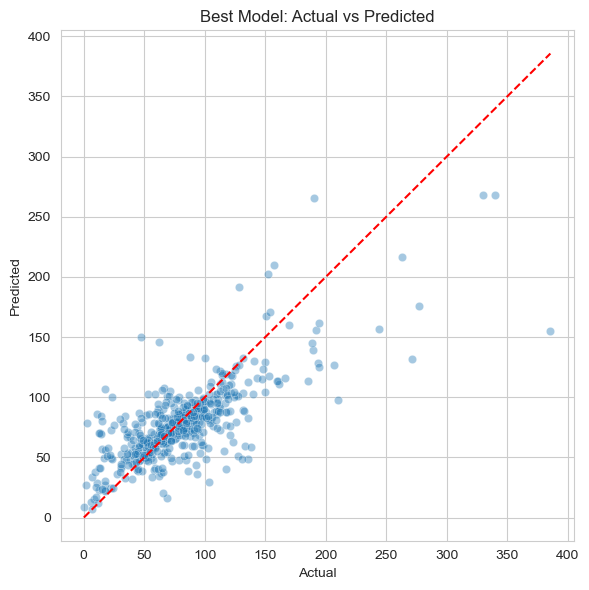

In [36]:
best_pipeline = tuned_rf
best_predictions = tuned_rf_predictions

comparison_df = pd.DataFrame({
    "actual": y_test,
    "predicted": best_predictions,
}).sample(min(500, len(y_test)), random_state=42)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparison_df, x="actual", y="predicted", alpha=0.4)
lims = [
    min(comparison_df["actual"].min(), comparison_df["predicted"].min()),
    max(comparison_df["actual"].max(), comparison_df["predicted"].max()),
]
plt.plot(lims, lims, color="red", linestyle="--")
plt.title("Best Model: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


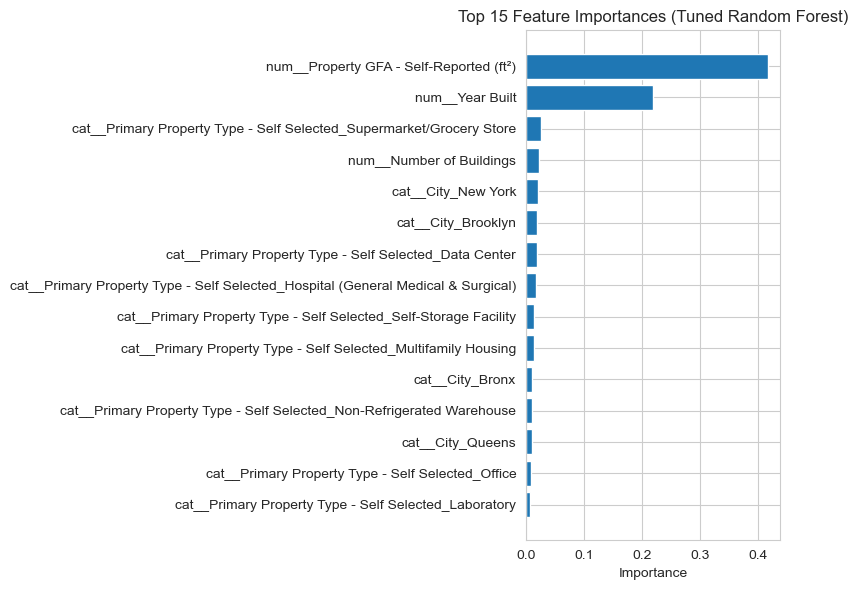

,feature,importance
1,num__Property GFA - Self-Reported (ft²),0.417557
0,num__Year Built,0.218618
70,cat__Primary Property Type - Self Selected_Sup...,0.025959
2,num__Number of Buildings,0.022518
273,cat__City_New York,0.019915
128,cat__City_Brooklyn,0.019514
13,cat__Primary Property Type - Self Selected_Dat...,0.018415
22,cat__Primary Property Type - Self Selected_Hos...,0.016773
64,cat__Primary Property Type - Self Selected_Sel...,0.014537
35,cat__Primary Property Type - Self Selected_Mul...,0.013406


In [37]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_pipeline.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

top_feature_importance = feature_importance.head(15).sort_values("importance")
plt.figure(figsize=(8, 6))
plt.barh(top_feature_importance["feature"], top_feature_importance["importance"])
plt.title("Top 15 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance.head(10)


In [38]:
sensitivity_results = []
for label, q in [("P95", 0.95), ("P99", 0.99), ("NoUpperCap", 1.0)]:
    q_df = df.dropna(subset=[target]).copy()
    upper = q_df[target].quantile(q)
    q_df = q_df[q_df[target] > 0].copy()
    if q < 1.0:
        q_df = q_df[q_df[target] <= upper].copy()

    X_q = q_df[features]
    y_q = q_df[target]
    X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
        X_q, y_q, test_size=0.2, random_state=42
    )

    rf_q = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)),
    ])
    rf_q.fit(X_train_q, y_train_q)
    pred_q = rf_q.predict(X_test_q)

    sensitivity_results.append({
        "target_filter": label,
        "rows": len(q_df),
        "MAE": mean_absolute_error(y_test_q, pred_q),
        "RMSE": mean_squared_error(y_test_q, pred_q) ** 0.5,
        "R2": r2_score(y_test_q, pred_q),
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.round(3)


,target_filter,rows,MAE,RMSE,R2
0,P95,81502,16.323,23.643,0.473
1,P99,84942,20.149,33.261,0.492
2,NoUpperCap,85803,5248.928,194042.469,0.346


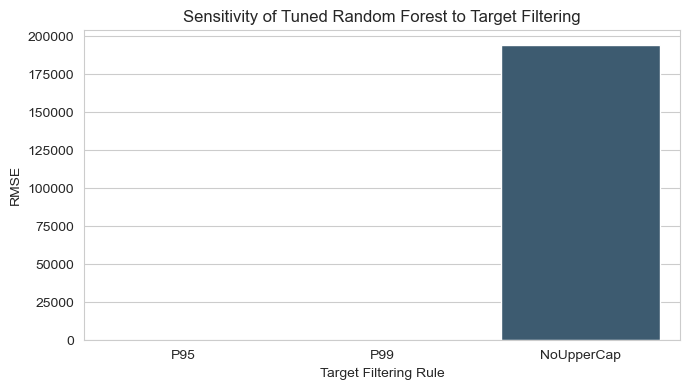

In [39]:
plt.figure(figsize=(7, 4))
sns.barplot(data=sensitivity_df, x="target_filter", y="RMSE", hue="target_filter", legend=False, palette="Blues_d")
plt.title("Sensitivity of Tuned Random Forest to Target Filtering")
plt.ylabel("RMSE")
plt.xlabel("Target Filtering Rule")
plt.tight_layout()
plt.show()


## 6. Error Analysis for the Tuned Random Forest

A stronger project notebook should not stop at aggregate metrics. The next cells diagnose where the tuned random forest still makes mistakes by inspecting residuals, score-range error patterns, and property-type variation in absolute error.


In [41]:
tuned_eval_df = X_test.copy()
tuned_eval_df["actual"] = y_test
tuned_eval_df["predicted"] = tuned_rf_predictions
tuned_eval_df["residual"] = tuned_eval_df["actual"] - tuned_eval_df["predicted"]
tuned_eval_df["abs_error"] = tuned_eval_df["residual"].abs()
tuned_eval_df.head()


,Year Built,Property GFA - Self-Reported (ft²),Number of Buildings,Primary Property Type - Self Selected,City,actual,predicted,residual,abs_error
24229,1900,55460.0,1,Multifamily Housing,New York,22.9,68.880204,-45.980204,45.980204
22519,1915,33000.0,1,Multifamily Housing,New York,58.3,126.858277,-68.558277,68.558277
5412,1951,137650.0,1,Multifamily Housing,Queens,85.5,90.269831,-4.769831,4.769831
83880,1927,106550.0,1,Multifamily Housing,Bronx,109.6,88.286947,21.313053,21.313053
59322,1963,142441.0,1,Multifamily Housing,Brooklyn,75.4,73.910529,1.489471,1.489471


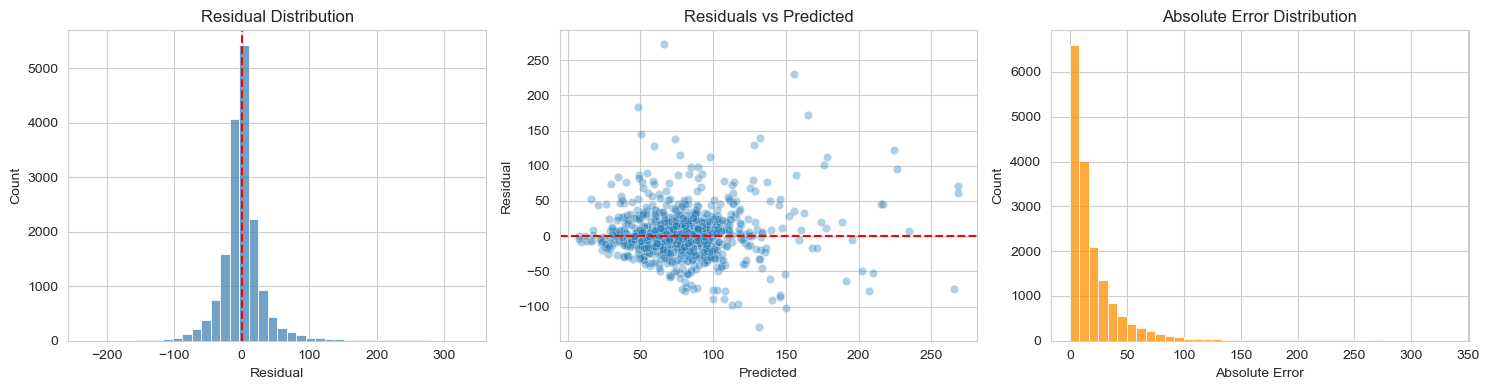

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(tuned_eval_df["residual"], bins=40, color="steelblue", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual")

sns.scatterplot(data=tuned_eval_df.sample(min(1000, len(tuned_eval_df)), random_state=42),
                x="predicted", y="residual", alpha=0.35, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

sns.histplot(tuned_eval_df["abs_error"], bins=40, color="darkorange", ax=axes[2])
axes[2].set_title("Absolute Error Distribution")
axes[2].set_xlabel("Absolute Error")

plt.tight_layout()
plt.show()


In [43]:
score_bins = [0, 50, 100, 150, 250, float("inf")]
score_labels = ["0-50", "51-100", "101-150", "151-250", "250+"]
tuned_eval_df["score_band"] = pd.cut(
    tuned_eval_df["actual"], bins=score_bins, labels=score_labels, include_lowest=True
)

score_band_error = tuned_eval_df.groupby("score_band", observed=False).agg(
    test_rows=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_abs_error=("abs_error", "median"),
).reset_index()
score_band_error.round(3)


,score_band,test_rows,mean_abs_error,median_abs_error
0,0-50,3860,25.950,18.625
1,51-100,9393,11.252,7.833
2,101-150,2767,23.076,18.355
3,151-250,761,58.512,52.357
4,250+,208,134.966,127.137


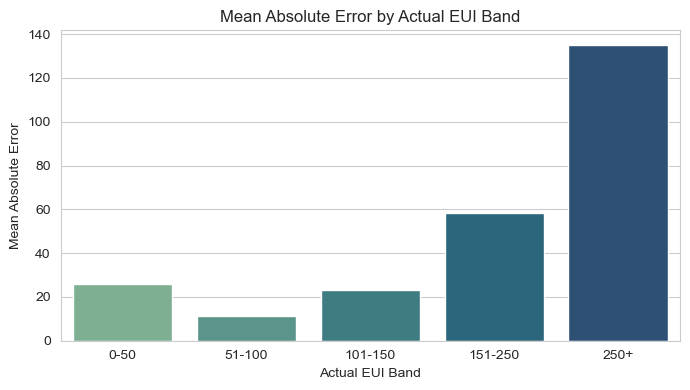

In [44]:
plt.figure(figsize=(7, 4))
sns.barplot(data=score_band_error, x="score_band", y="mean_abs_error", hue="score_band", legend=False, palette="crest")
plt.title("Mean Absolute Error by Actual EUI Band")
plt.xlabel("Actual EUI Band")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()


In [45]:
property_type_error = tuned_eval_df.groupby("Primary Property Type - Self Selected").agg(
    test_rows=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_abs_error=("abs_error", "median"),
).reset_index()

property_type_error = property_type_error[property_type_error["test_rows"] >= 30].copy()
hardest_types = property_type_error.sort_values("mean_abs_error", ascending=False).head(10)
easiest_types = property_type_error.sort_values("mean_abs_error", ascending=True).head(10)

display(hardest_types.round(3))
display(easiest_types.round(3))


,Primary Property Type - Self Selected,test_rows,mean_abs_error,median_abs_error
39,Other - Recreation,119,57.460,40.163
67,Vehicle Repair Services,56,51.248,41.774
63,Supermarket/Grocery Store,60,43.869,31.266
55,Residential Care Facility,58,36.472,25.459
62,Strip Mall,64,35.593,24.657
10,Data Center,37,35.153,30.954
27,Mixed Use Property,144,33.988,21.797
18,Hospital (General Medical & Surgical),38,33.908,22.195
7,College/University,136,32.660,23.846
26,Medical Office,60,32.179,20.816


,Primary Property Type - Self Selected,test_rows,mean_abs_error,median_abs_error
58,Self-Storage Facility,153,8.751,5.235
50,Pre-school/Daycare,79,14.303,6.824
21,K-12 School,1043,14.381,10.186
32,Office,1309,18.125,11.709
29,Multifamily Housing,11380,18.356,10.714
11,Distribution Center,111,18.414,12.977
23,Library,52,18.435,14.394
14,Fire Station,34,18.878,11.390
31,Non-Refrigerated Warehouse,265,20.035,12.538
72,Worship Facility,109,21.319,14.445


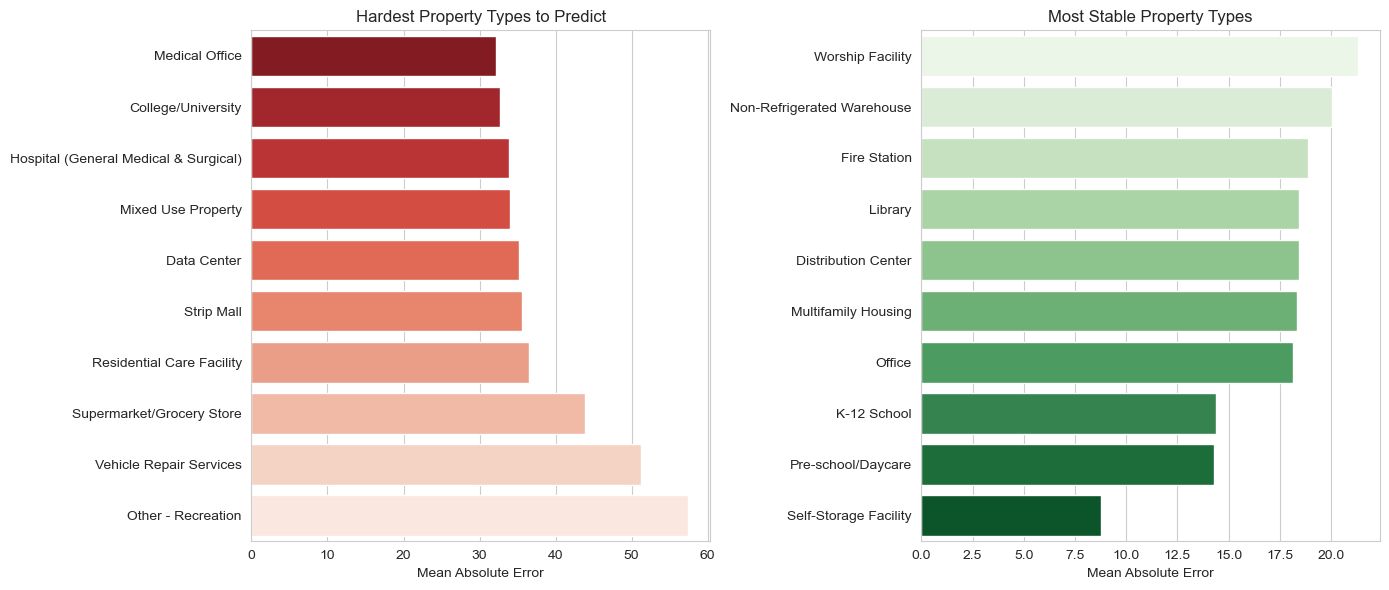

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=hardest_types.sort_values("mean_abs_error"),
            x="mean_abs_error", y="Primary Property Type - Self Selected",
            hue="Primary Property Type - Self Selected", legend=False, palette="Reds_r", ax=axes[0])
axes[0].set_title("Hardest Property Types to Predict")
axes[0].set_xlabel("Mean Absolute Error")
axes[0].set_ylabel("")

sns.barplot(data=easiest_types.sort_values("mean_abs_error", ascending=False),
            x="mean_abs_error", y="Primary Property Type - Self Selected",
            hue="Primary Property Type - Self Selected", legend=False, palette="Greens", ax=axes[1])
axes[1].set_title("Most Stable Property Types")
axes[1].set_xlabel("Mean Absolute Error")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 7. Tuned vs. Baseline Random Forest Comparison

The next step checks whether tuning produced a real improvement over the original random forest. In this notebook, tuning is treated as an empirical test rather than an assumption: if the tuned model underperforms, the stronger untuned baseline remains the final choice.


In [48]:
rf_compare_df = pd.DataFrame({
    "actual": y_test,
    "baseline_rf_pred": baseline_rf_predictions,
    "tuned_rf_pred": tuned_rf_predictions,
})
rf_compare_df["baseline_abs_error"] = (rf_compare_df["actual"] - rf_compare_df["baseline_rf_pred"]).abs()
rf_compare_df["tuned_abs_error"] = (rf_compare_df["actual"] - rf_compare_df["tuned_rf_pred"]).abs()
rf_compare_df["error_improvement"] = rf_compare_df["baseline_abs_error"] - rf_compare_df["tuned_abs_error"]
rf_compare_df["winner"] = np.where(
    rf_compare_df["error_improvement"] > 0, "Tuned RF",
    np.where(rf_compare_df["error_improvement"] < 0, "Baseline RF", "Tie")
)

rf_comparison_summary = pd.DataFrame([
    {
        "metric": "MAE",
        "baseline_rf": mean_absolute_error(y_test, baseline_rf_predictions),
        "tuned_rf": mean_absolute_error(y_test, tuned_rf_predictions),
    },
    {
        "metric": "RMSE",
        "baseline_rf": mean_squared_error(y_test, baseline_rf_predictions) ** 0.5,
        "tuned_rf": mean_squared_error(y_test, tuned_rf_predictions) ** 0.5,
    },
    {
        "metric": "R2",
        "baseline_rf": r2_score(y_test, baseline_rf_predictions),
        "tuned_rf": r2_score(y_test, tuned_rf_predictions),
    },
])
rf_comparison_summary["delta_(tuned-baseline)"] = rf_comparison_summary["tuned_rf"] - rf_comparison_summary["baseline_rf"]
rf_comparison_summary.round(4)


,metric,baseline_rf,tuned_rf,delta_(tuned-baseline)
0,MAE,20.1783,20.1492,-0.0291
1,RMSE,33.3306,33.2605,-0.0701
2,R2,0.4900,0.4921,0.0021


In [49]:
rf_compare_df["winner"].value_counts()


winner
Tuned RF       8663
Baseline RF    8326
Name: count, dtype: int64

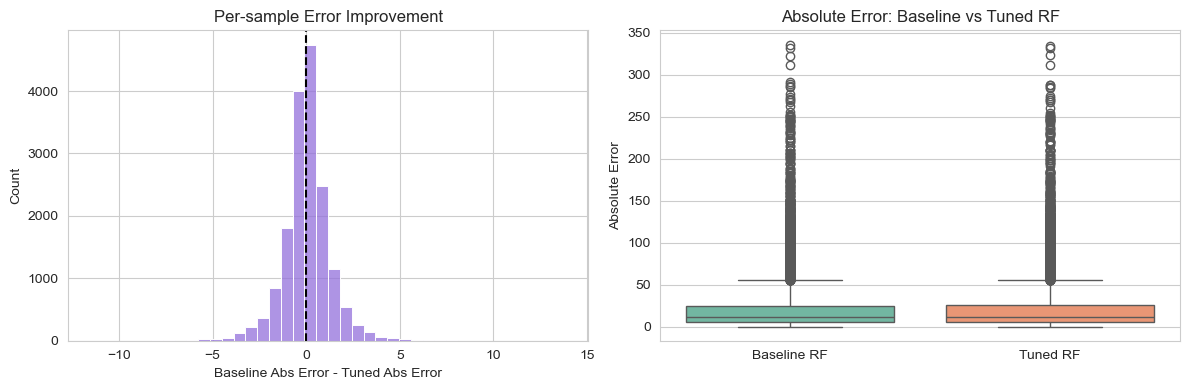

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(rf_compare_df["error_improvement"], bins=40, color="mediumpurple", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Per-sample Error Improvement")
axes[0].set_xlabel("Baseline Abs Error - Tuned Abs Error")

comparison_long = rf_compare_df[["baseline_abs_error", "tuned_abs_error"]].rename(columns={
    "baseline_abs_error": "Baseline RF",
    "tuned_abs_error": "Tuned RF",
}).melt(var_name="model", value_name="abs_error")
sns.boxplot(data=comparison_long, x="model", y="abs_error", hue="model", legend=False, palette="Set2", ax=axes[1])
axes[1].set_title("Absolute Error: Baseline vs Tuned RF")
axes[1].set_xlabel("")
axes[1].set_ylabel("Absolute Error")

plt.tight_layout()
plt.show()


## 8. Summary

This final section converts the model-comparison, tuning, robustness, and error-analysis outputs into a concise set of report-ready conclusions.


In [71]:
hardest_type_name = hardest_types.iloc[0]["Primary Property Type - Self Selected"] if len(hardest_types) else "N/A"
hardest_type_mae = hardest_types.iloc[0]["mean_abs_error"] if len(hardest_types) else float("nan")
best_band = score_band_error.sort_values("mean_abs_error").iloc[0]["score_band"]
baseline_rf_mae = mean_absolute_error(y_test, baseline_rf_predictions)
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_predictions)
baseline_rf_rmse = mean_squared_error(y_test, baseline_rf_predictions) ** 0.5
tuned_rf_rmse = mean_squared_error(y_test, tuned_rf_predictions) ** 0.5
baseline_rf_r2 = r2_score(y_test, baseline_rf_predictions)
tuned_rf_r2 = r2_score(y_test, tuned_rf_predictions)
tuned_beats = (rf_compare_df["winner"] == "Tuned RF").sum()
baseline_beats = (rf_compare_df["winner"] == "Baseline RF").sum()

summary_lines = [
    f"1. The strongest baseline model is RandomForestRegressor with MAE {baseline_rf_mae:.2f}, RMSE {baseline_rf_rmse:.2f}, and R² {baseline_rf_r2:.3f}.",
    f"2. Validation-based tuning selects {best_candidate_name} and yields a modest improvement: tuned RF reaches MAE {tuned_rf_mae:.2f}, RMSE {tuned_rf_rmse:.2f}, and R² {tuned_rf_r2:.3f}.",
    f"3. The tuned model improves aggregate performance only slightly, but it still outperforms the baseline RF on {tuned_beats} test cases versus {baseline_beats} for the baseline.",
    f"4. XGBRegressor adds a stronger nonlinear comparison, but it remains weaker than the random-forest models in this feature scope.",
    f"5. The robustness and error-analysis results show that the model is most accurate in the {best_band} EUI band and struggles most for property types such as {hardest_type_name} (mean absolute error {hardest_type_mae:.2f}).",
    "6. Overall, the final workflow is stronger than a simple baseline notebook because it combines baseline comparison, targeted tuning, sensitivity analysis, and post-model diagnostics.",
]

for line in summary_lines:
    print(line)


1. The strongest baseline model is RandomForestRegressor with MAE 20.18, RMSE 33.33, and R² 0.490.
2. Validation-based tuning selects more_trees_wider and yields a modest improvement: tuned RF reaches MAE 20.15, RMSE 33.26, and R² 0.492.
3. The tuned model improves aggregate performance only slightly, but it still outperforms the baseline RF on 8663 test cases versus 8326 for the baseline.
4. XGBRegressor adds a stronger nonlinear comparison, but it remains weaker than the random-forest models in this feature scope.
5. The robustness and error-analysis results show that the model is most accurate in the 51-100 EUI band and struggles most for property types such as Other - Recreation (mean absolute error 57.46).
6. Overall, the final workflow is stronger than a simple baseline notebook because it combines baseline comparison, targeted tuning, sensitivity analysis, and post-model diagnostics.
